In [68]:
# Matplotlib
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
path_nout_csv = Path('new_laptop.csv')

In [9]:
if path_nout_csv.exists():
    df = pd.read_csv(path_nout_csv, encoding='utf-8')
    print("OK")
else:
    print('No file found')

OK


In [10]:
df.shape

(1302, 16)

In [11]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros', 'Ram_GB', 'Weight_kg', 'Price_group'],
      dtype='str')

In [12]:
first_prices = df["Price_euros"].head(3)

In [13]:
first_prices

0     898.94
1     575.00
2    2537.45
Name: Price_euros, dtype: float64

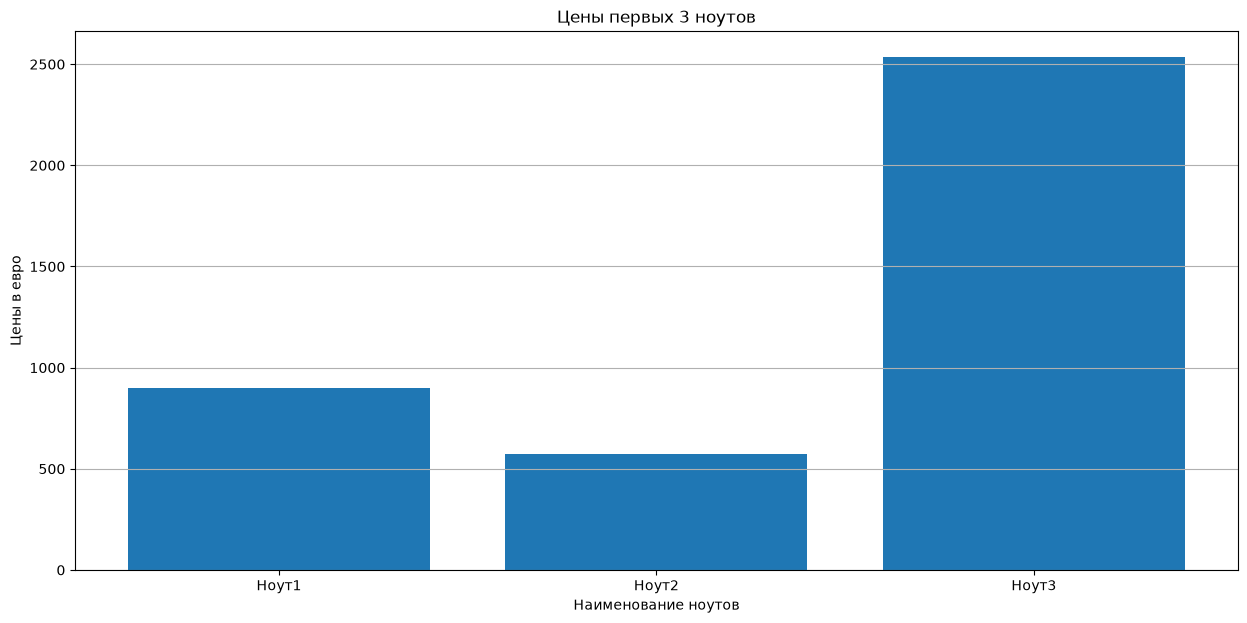

In [25]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.bar(["Ноут1", "Ноут2", "Ноут3"], first_prices)
ax.set_title("Цены первых 3 ноутов")
ax.set_xlabel("Наименование ноутов")
ax.set_ylabel("Цены в евро")
ax.grid(True, axis="y")
plt.show()

In [26]:
prices = df["Price_euros"]

In [ ]:
%%sql


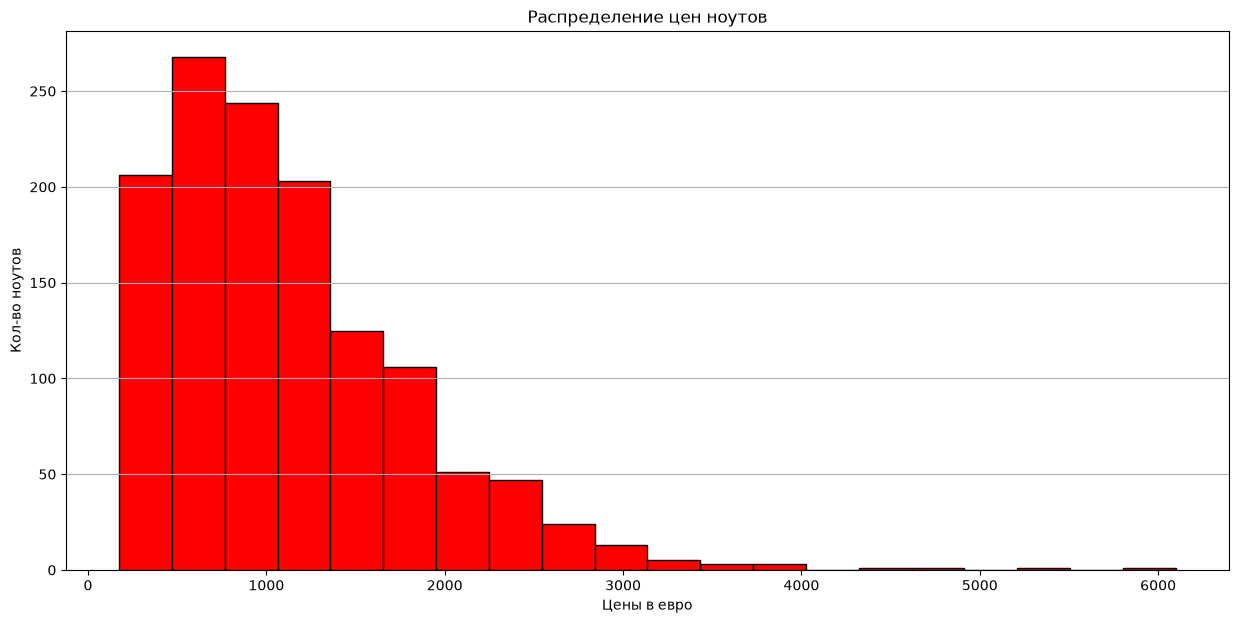

In [29]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.hist(prices, bins=20, color="red", edgecolor="black")
ax.set_title("Распределение цен ноутов")
ax.set_xlabel("Цены в евро")
ax.set_ylabel("Кол-во ноутов")
ax.grid(True, axis="y")
plt.show()

In [33]:
company_counts = df["Company"].value_counts()
top_companies = company_counts.head(7)
top_companies

Company
Dell       297
Lenovo     297
HP         274
Asus       158
Acer       103
MSI         54
Toshiba     48
Name: count, dtype: int64

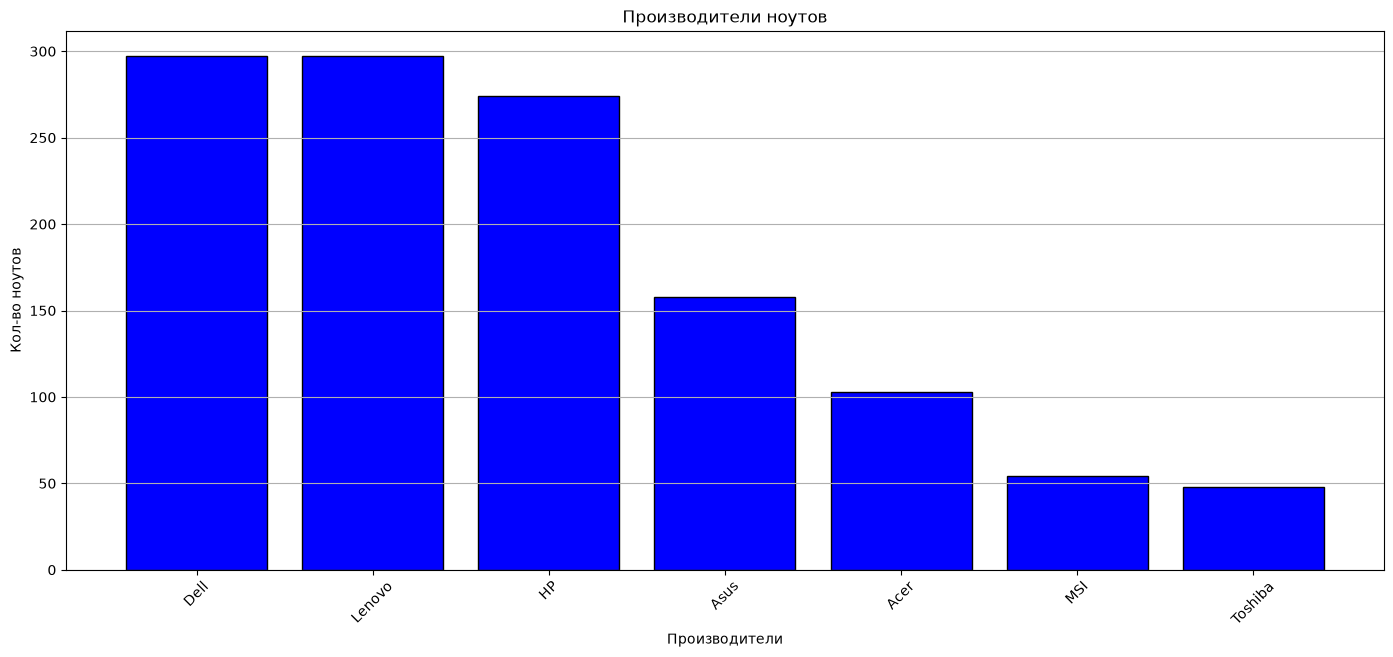

In [43]:
fig, ax = plt.subplots(figsize=(17, 7))
ax.bar(top_companies.index, top_companies.values, color="blue", edgecolor="black")
ax.set_title("Производители ноутов")
ax.set_xlabel("Производители")
ax.set_ylabel("Кол-во ноутов")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y")
fig.tight_layout()
plt.show()

In [46]:
os_counts = df["OpSys"].value_counts()
os_counts

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             12
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [47]:
os_for_pie = os_counts.head(6).copy()

In [48]:
other_count = os_counts.iloc[6:].sum()
os_for_pie.loc["Другие"] = other_count

In [49]:
os_for_pie

OpSys
Windows 10    1072
No OS           66
Linux           62
Windows 7       45
Chrome OS       27
macOS           12
Другие          18
Name: count, dtype: int64

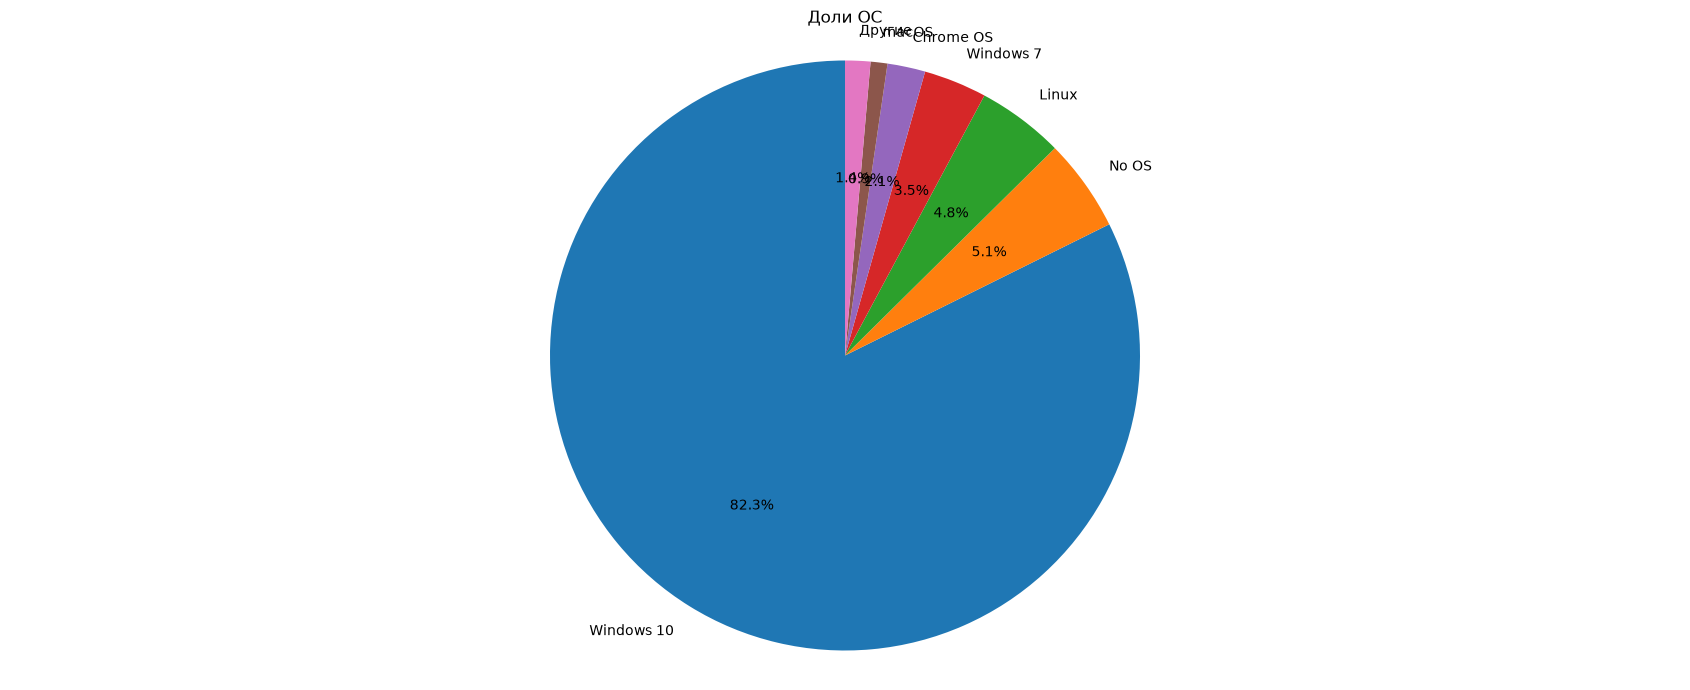

In [52]:
fig, ax = plt.subplots(figsize=(17, 7))
ax.pie(os_for_pie.values, labels=os_for_pie.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Доли ОС")
ax.axis("equal")

fig.tight_layout()
plt.show()

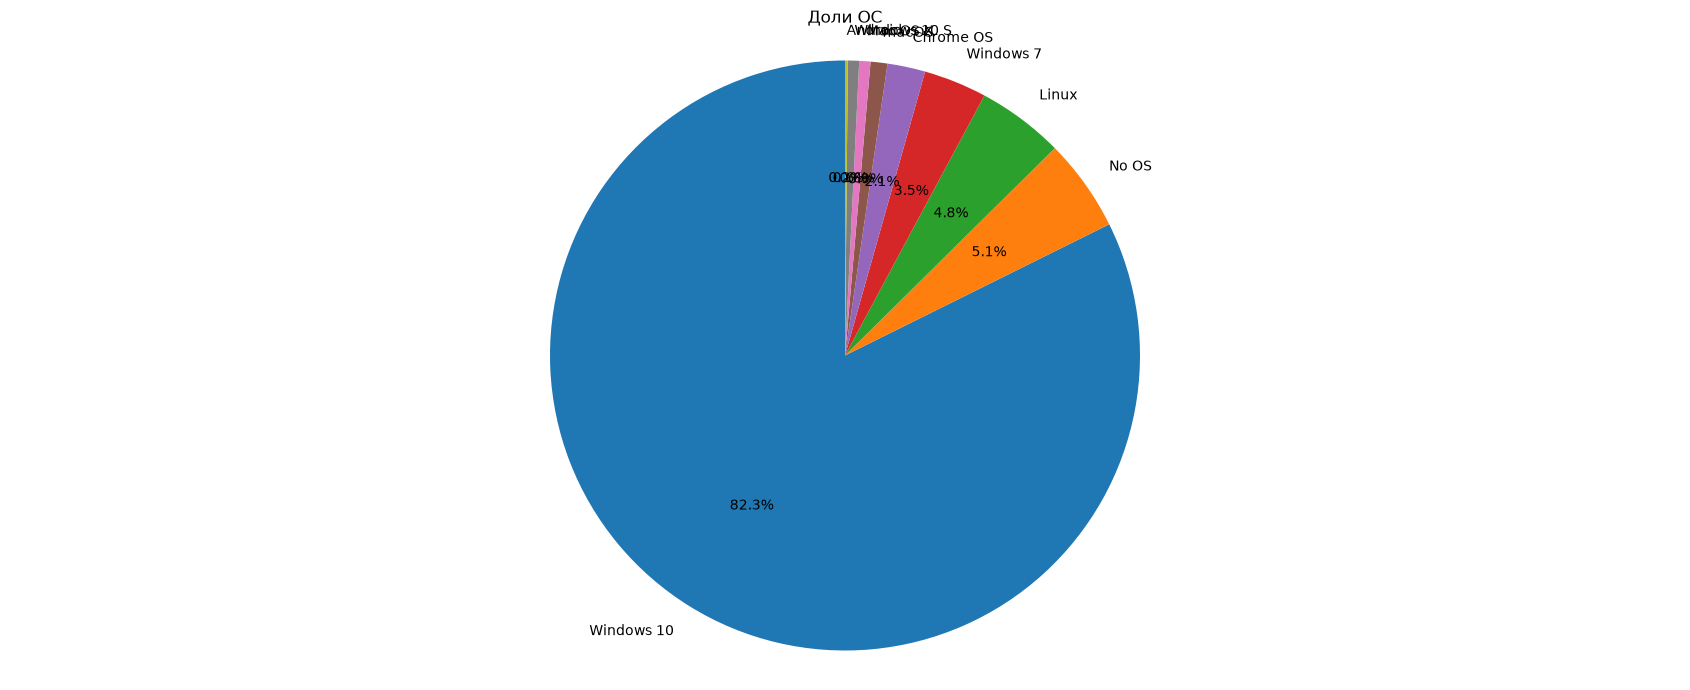

In [53]:
fig, ax = plt.subplots(figsize=(17, 7))
ax.pie(os_counts.values, labels=os_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Доли ОС")
ax.axis("equal")

fig.tight_layout()
plt.show()

In [54]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Ram_GB,Weight_kg,Price_group
0,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,8,1.34,До 1000 евро
1,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,8,1.86,До 1000 евро
2,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,16,1.83,От 1000 евро
3,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,8,1.37,От 1000 евро
4,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00,4,2.10,До 1000 евро


In [55]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros', 'Ram_GB', 'Weight_kg', 'Price_group'],
      dtype='str')

In [57]:
notebooks = df[df["TypeName"] == "Notebook"]
notebooks.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Ram_GB,Weight_kg,Price_group
1,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,8,1.86,До 1000 евро
4,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00,4,2.10,До 1000 евро
9,11,HP,250 G6,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,No OS,1.86kg,393.90,4,1.86,До 1000 евро
10,12,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4GB,500GB HDD,Intel HD Graphics 520,No OS,1.86kg,344.99,4,1.86,До 1000 евро
12,14,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4GB,256GB SSD,AMD Radeon R5 M430,Windows 10,2.2kg,498.90,4,2.20,До 1000 евро


In [58]:
gaming_notebooks = df[df["TypeName"] == "Gaming"]
gaming_notebooks.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Ram_GB,Weight_kg,Price_group
20,22,Lenovo,Legion Y520-15IKBN,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.5kg,999.0,8,2.50,До 1000 евро
40,42,Dell,Inspiron 7577,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.65kg,1499.0,16,2.65,От 1000 евро
46,48,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1700 3GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1299.0,8,3.20,От 1000 евро
57,59,MSI,GS73VR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 2TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.43kg,2449.0,16,2.43,От 1000 евро
68,71,Asus,FX753VE-GC093 (i7-7700HQ/12GB/1TB/GeForce,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,12GB,1TB HDD,Nvidia GeForce GTX 1050 Ti,Linux,3kg,949.0,12,3.00,До 1000 евро


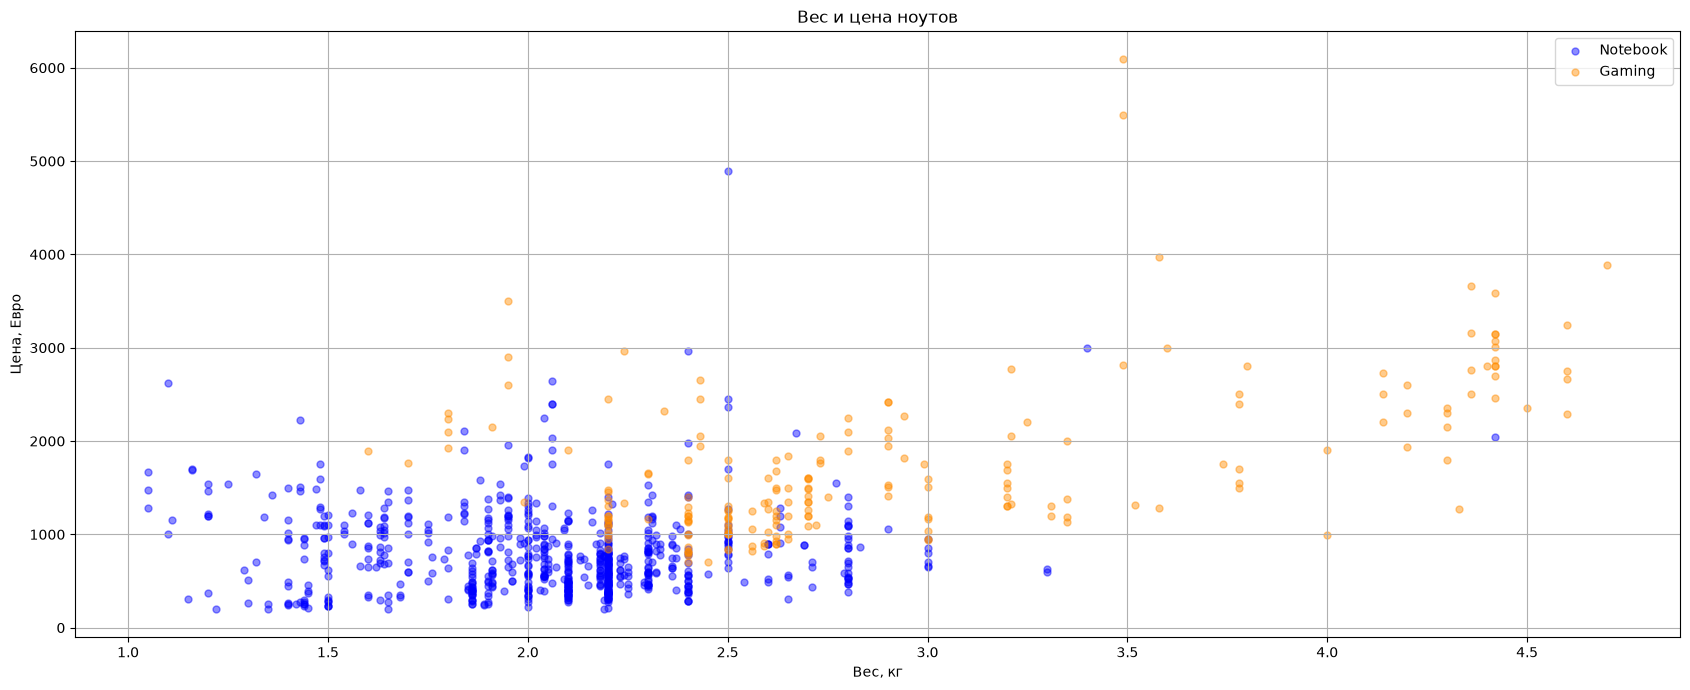

In [60]:
fig, ax = plt.subplots(figsize=(17, 7))
ax.scatter(
    notebooks["Weight_kg"],
    notebooks["Price_euros"],
    s=25,
    alpha=0.45,
    color="blue",
    label="Notebook"
)

ax.scatter(
    gaming_notebooks["Weight_kg"],
    gaming_notebooks["Price_euros"],
    s=25,
    alpha=0.45,
    color="darkorange",
    label="Gaming"
)

ax.set_title("Вес и цена ноутов")
ax.set_xlabel("Вес, кг")
ax.set_ylabel("Цена, Евро")
ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()

In [62]:
ram_stats = df.groupby("Ram_GB")["Price_euros"].agg(["count", "median"]).sort_index()
ram_stats

,count,median
Ram_GB,,
2,22,234.00
4,375,498.00
6,41,579.00
8,618,1099.00
12,25,1249.00
16,200,1890.50
24,3,2382.00
32,17,3147.37
64,1,3975.00


In [63]:
ram_for_plots = ram_stats[ram_stats["count"] >= 10]

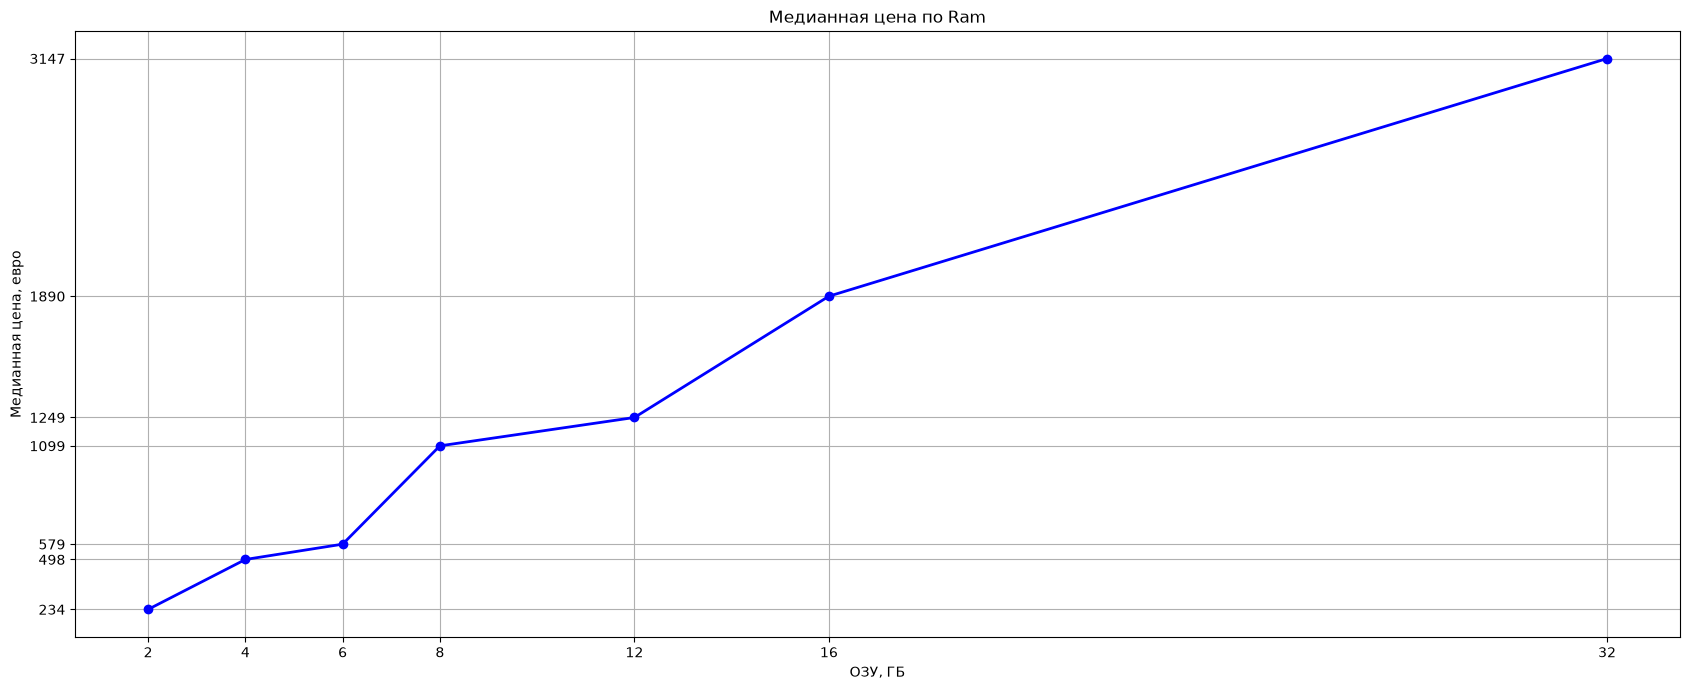

In [67]:
fig, ax = plt.subplots(figsize=(17, 7))
ax.plot(
    ram_for_plots.index,
    ram_for_plots["median"],
    marker="o",
    linestyle="-",
    linewidth=2,
    color="blue",
)
ax.set_xticks(ram_for_plots.index)
ax.set_yticks(ram_for_plots["median"])
ax.set_title("Медианная цена по Ram")
ax.set_xlabel("ОЗУ, ГБ")
ax.set_ylabel("Медианная цена, евро")
# ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()

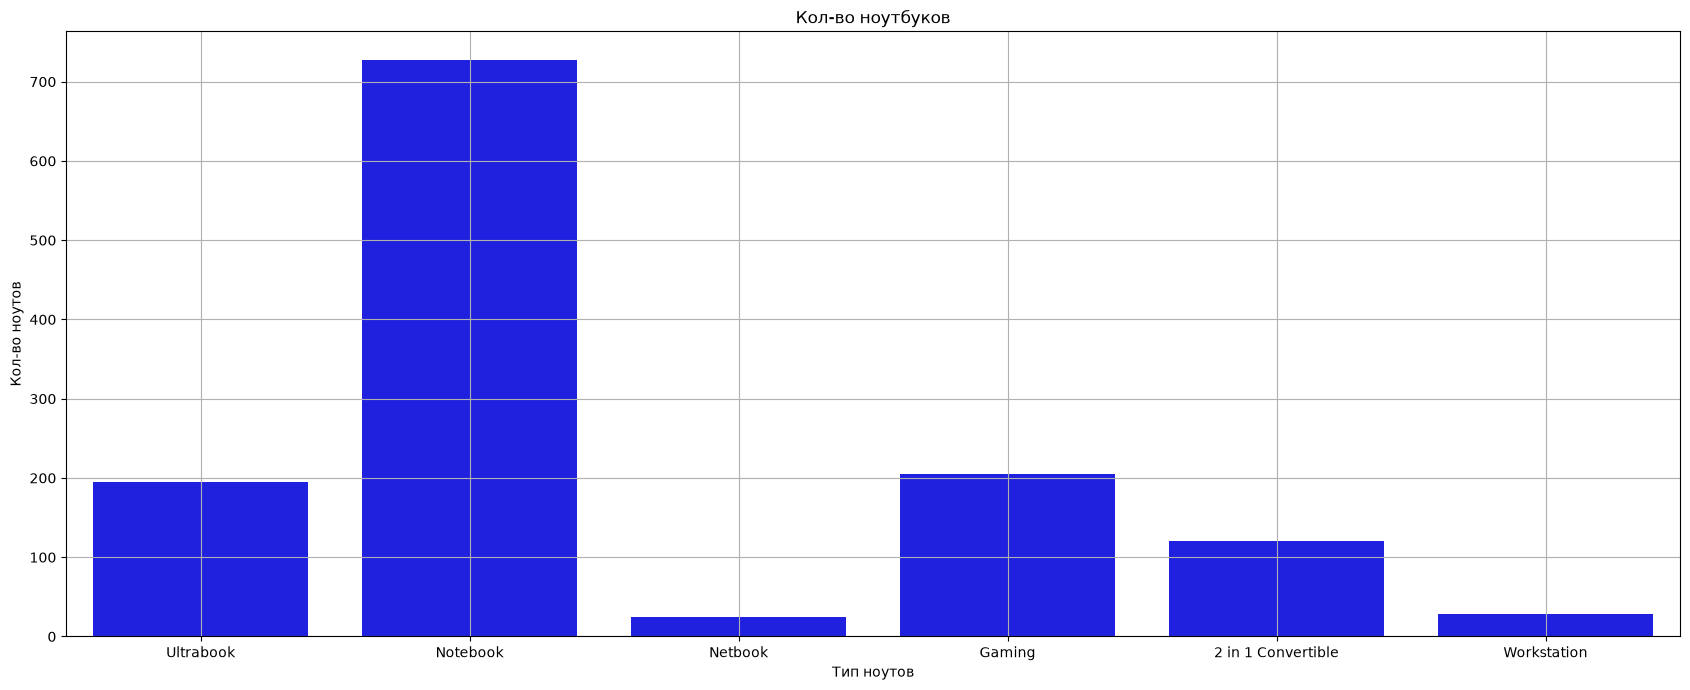

In [69]:
fig, ax = plt.subplots(figsize=(17, 7))
sns.countplot(
    data=df,
    x="TypeName",
    ax=ax,
    color="blue",
)
ax.set_title("Кол-во ноутбуков")
ax.set_xlabel("Тип ноутов")
ax.set_ylabel("Кол-во ноутов")
# ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()